In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

# Linear probes: neutral vs. combined / neutral vs. each technique (en + tl)

Mass-Mean (MM) probing, per the ARENA "Linear Probes" exercises
(https://github.com/callummcdougall/ARENA_3.0, part31_linear_probes):

    direction = mean(positive_activations) - mean(neutral_activations)

-- the same math as [compute_directions.py](../../compute_directions.py)'s
`mean_diff` method, evaluated here as a classifier (train/test accuracy)
rather than compared by cosine similarity. As with the earlier Tagalog-only
notebook, we add a midpoint decision threshold
(`((pos_mean + neg_mean) / 2) @ direction`) since the ARENA reference's bare
`sigmoid(x @ direction)` has no bias and assumes pre-centered activations.

**12 probes total**: for each of {english, tagalog} x {combined (all 5
techniques), authority, evidence, expert, logical, misrep} vs. that
language's `neutral`.

**Train/test**: 80/20 stratified split on `everyday`-category samples only
(in-domain). Each probe also gets evaluated -- not trained -- on the
`hs_*`-category samples (out-of-domain), as an additional generalization
check; this OOD number is not used to pick anything, just reported.

In [2]:
import itertools
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from safetensors import safe_open
from safetensors.torch import load_file
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [3]:
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RUN_DIR = PROJECT_ROOT / "data" / "activations" / "run_1"
DIRECTIONS_DIR = PROJECT_ROOT / "data" / "directions"

print("Resolved RUN_DIR:", RUN_DIR)
print("Exists:", RUN_DIR.exists())

Resolved RUN_DIR: C:\Users\THINKPAD T14\OneDrive\Documents\000 THINKPAD\Projects\Collab\APART Hackathon\apart-global-south-persuasion-project\data\activations\run_1
Exists: True


In [4]:
TECHNIQUE_SHORT = {
    "authority_endorsement_persuasion": "authority",
    "evidence_based_persuasion": "evidence",
    "expert_endorsement_persuasion": "expert",
    "logical_appeal_persuasion": "logical",
    "misrepresentation_persuasion": "misrep",
}

LANGUAGES = {
    "en": {
        "neutral": "neutral",
        "techniques": list(TECHNIQUE_SHORT.keys()),
    },
    "tl": {
        "neutral": "neutral_tl",
        "techniques": [t + "_tl" for t in TECHNIQUE_SHORT.keys()],
    },
}

ALL_LAYERS = list(range(36))
STEER_LAYERS = [12, 13, 14, 15, 20, 21, 22, 23, 24]  # layers actually used for steering

ID_FILTER_IN_DOMAIN = "everyday"
ID_FILTER_OOD = "hs_"

TEST_SIZE = 0.2
SPLIT_SEED = 42

### Loading

In [5]:
def load_activation_samples(folder: str, id_filter: str):
    """([n_samples, n_layers, hidden], ids) for one variant folder, filtered to ids containing id_filter."""
    path = RUN_DIR / folder / "mean_assistant_token.safetensors"
    with safe_open(str(path), framework="pt") as f:
        tensor = f.get_tensor("activations")
        ids = json.loads(f.metadata()["ids"])
    keep = [i for i, sample_id in enumerate(ids) if id_filter in sample_id]
    return tensor[keep].numpy(), [ids[i] for i in keep]


def build_dataset(neutral_folder: str, technique_folders: list[str], id_filter: str):
    """Pool neutral (label 0) vs. the given technique folder(s) (label 1, pooled together)."""
    neutral_acts, _ = load_activation_samples(neutral_folder, id_filter)
    technique_acts = np.concatenate(
        [load_activation_samples(t, id_filter)[0] for t in technique_folders], axis=0
    )
    X = np.concatenate([neutral_acts, technique_acts], axis=0)
    y = np.concatenate([np.zeros(len(neutral_acts)), np.ones(len(technique_acts))])
    return X, y

### MM probe

In [6]:
def fit_mm_direction(X_layer: np.ndarray, y_layer: np.ndarray):
    """direction = mean(positive) - mean(negative); plus a midpoint decision threshold."""
    pos_mean = X_layer[y_layer == 1].mean(axis=0)
    neg_mean = X_layer[y_layer == 0].mean(axis=0)
    direction = pos_mean - neg_mean
    threshold = ((pos_mean + neg_mean) / 2) @ direction
    return direction, threshold


def mm_predict(X_layer: np.ndarray, direction: np.ndarray, threshold: float) -> np.ndarray:
    return (X_layer @ direction > threshold).astype(int)

### Probe specs

One spec per (language, technique-group): `combined` pools all 5 techniques
as the positive class; the other 5 use a single technique each.

In [7]:
PROBE_SPECS = []
for lang, cfg in LANGUAGES.items():
    PROBE_SPECS.append({"lang": lang, "technique": "combined", "folders": cfg["techniques"]})
    for full_name, short in TECHNIQUE_SHORT.items():
        folder = full_name + ("_tl" if lang == "tl" else "")
        PROBE_SPECS.append({"lang": lang, "technique": short, "folders": [folder]})

print(f"{len(PROBE_SPECS)} probes:")
for spec in PROBE_SPECS:
    print(" ", spec["lang"], spec["technique"], spec["folders"])

12 probes:
  en combined ['authority_endorsement_persuasion', 'evidence_based_persuasion', 'expert_endorsement_persuasion', 'logical_appeal_persuasion', 'misrepresentation_persuasion']
  en authority ['authority_endorsement_persuasion']
  en evidence ['evidence_based_persuasion']
  en expert ['expert_endorsement_persuasion']
  en logical ['logical_appeal_persuasion']
  en misrep ['misrepresentation_persuasion']
  tl combined ['authority_endorsement_persuasion_tl', 'evidence_based_persuasion_tl', 'expert_endorsement_persuasion_tl', 'logical_appeal_persuasion_tl', 'misrepresentation_persuasion_tl']
  tl authority ['authority_endorsement_persuasion_tl']
  tl evidence ['evidence_based_persuasion_tl']
  tl expert ['expert_endorsement_persuasion_tl']
  tl logical ['logical_appeal_persuasion_tl']
  tl misrep ['misrepresentation_persuasion_tl']


### Run all probes: 80/20 stratified in-domain (everyday) + OOD eval (hs_*)

In [8]:
results = []
for spec in PROBE_SPECS:
    lang, technique = spec["lang"], spec["technique"]
    neutral_folder = LANGUAGES[lang]["neutral"]

    X_id, y_id = build_dataset(neutral_folder, spec["folders"], ID_FILTER_IN_DOMAIN)
    X_ood, y_ood = build_dataset(neutral_folder, spec["folders"], ID_FILTER_OOD)

    train_idx, test_idx = train_test_split(
        np.arange(len(y_id)), test_size=TEST_SIZE, stratify=y_id, random_state=SPLIT_SEED
    )
    y_train, y_test = y_id[train_idx], y_id[test_idx]

    for layer in ALL_LAYERS:
        X_train_l, X_test_l = X_id[train_idx, layer, :], X_id[test_idx, layer, :]
        X_ood_l = X_ood[:, layer, :]

        direction, threshold = fit_mm_direction(X_train_l, y_train)

        train_pred = mm_predict(X_train_l, direction, threshold)
        test_pred = mm_predict(X_test_l, direction, threshold)
        ood_pred = mm_predict(X_ood_l, direction, threshold)

        results.append({
            "lang": lang,
            "technique": technique,
            "layer": layer,
            "is_steer_layer": layer in STEER_LAYERS,
            "train_accuracy": accuracy_score(y_train, train_pred),
            "test_accuracy": accuracy_score(y_test, test_pred),
            "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
            "ood_accuracy": accuracy_score(y_ood, ood_pred),
            "ood_balanced_accuracy": balanced_accuracy_score(y_ood, ood_pred),
        })

results_df = pd.DataFrame(results)
print(f"{len(results_df)} rows ({len(PROBE_SPECS)} probes x {len(ALL_LAYERS)} layers)")
results_df.head()

432 rows (12 probes x 36 layers)


,lang,technique,layer,is_steer_layer,train_accuracy,test_accuracy,test_balanced_accuracy,ood_accuracy,ood_balanced_accuracy
0,en,combined,0,False,0.997917,1.0,1.0,0.980000,0.940
1,en,combined,1,False,1.000000,1.0,1.0,0.990000,0.970
2,en,combined,2,False,0.997917,1.0,1.0,0.975000,0.925
3,en,combined,3,False,1.000000,1.0,1.0,0.998333,0.995
4,en,combined,4,False,1.000000,1.0,1.0,1.000000,1.000


### Best layer per probe (by in-domain test balanced accuracy)

In [9]:
best_per_probe = (
    results_df.sort_values("test_balanced_accuracy", ascending=False)
    .groupby(["lang", "technique"], sort=False)
    .first()
    .reset_index()[["lang", "technique", "layer", "train_accuracy", "test_accuracy",
                     "test_balanced_accuracy", "ood_accuracy", "ood_balanced_accuracy"]]
)
best_per_probe

,lang,technique,layer,train_accuracy,test_accuracy,test_balanced_accuracy,ood_accuracy,ood_balanced_accuracy
0,tl,misrep,19,1.00000,1.0,1.0,0.995000,0.995
1,en,combined,31,1.00000,1.0,1.0,0.978333,0.935
2,en,authority,11,1.00000,1.0,1.0,0.970000,0.970
3,en,evidence,7,1.00000,1.0,1.0,1.000000,1.000
4,en,expert,3,1.00000,1.0,1.0,0.990000,0.990
5,en,logical,15,1.00000,1.0,1.0,1.000000,1.000
6,en,misrep,11,1.00000,1.0,1.0,0.950000,0.950
7,tl,combined,7,1.00000,1.0,1.0,0.991667,0.975
8,tl,authority,3,0.99375,1.0,1.0,0.995000,0.995
9,tl,logical,34,0.99375,1.0,1.0,0.980000,0.980


### Heatmaps: accuracy per (language, technique) x layer

In-domain (everyday, held-out test split) on top; out-of-domain (hs_*,
never trained on -- additional insight only) below. Steering layers
(12-15, 20-24) are marked on the x-axis.

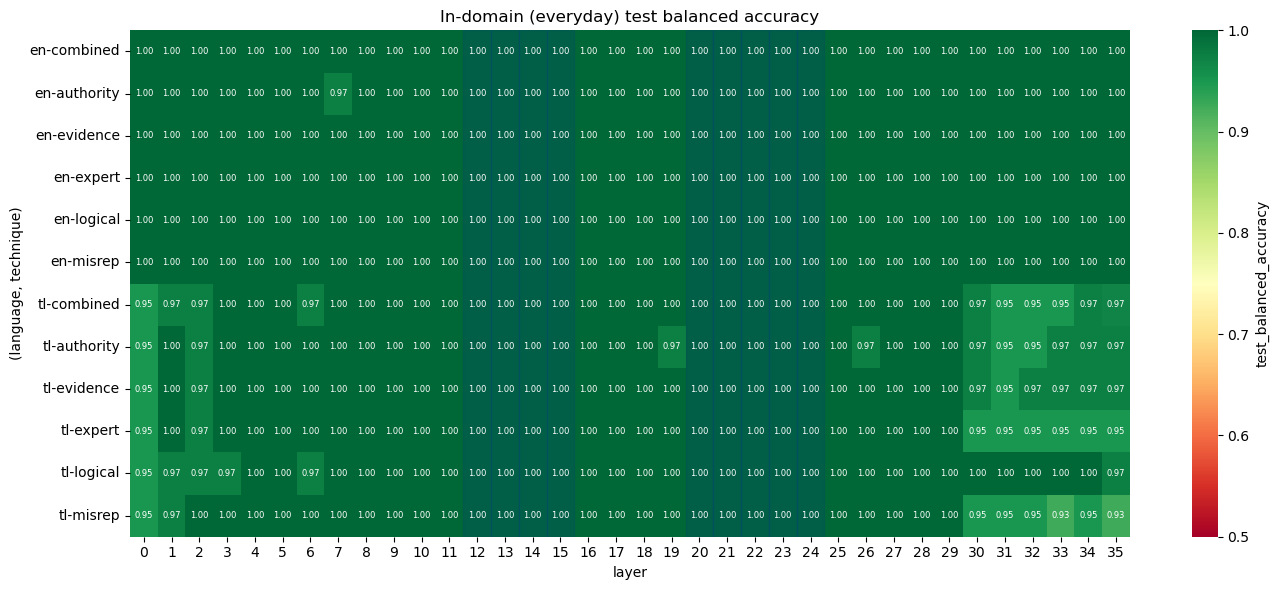

In [10]:
def plot_accuracy_heatmap(df, value_col, title):
    pivot = df.pivot(index=["lang", "technique"], columns="layer", values=value_col)
    pivot = pivot.reindex(
        [(lang, t["technique"]) for lang in LANGUAGES for t in PROBE_SPECS if t["lang"] == lang]
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="RdYlGn",
        vmin=0.5,
        vmax=1.0,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 6},
        cbar_kws={"label": value_col},
    )
    for layer in STEER_LAYERS:
        ax.axvspan(layer, layer + 1, color="blue", alpha=0.08)
    ax.set_title(title)
    ax.set_xlabel("layer")
    ax.set_ylabel("(language, technique)")
    fig.tight_layout()
    return fig


plot_accuracy_heatmap(results_df, "test_balanced_accuracy", "In-domain (everyday) test balanced accuracy")
plt.show()

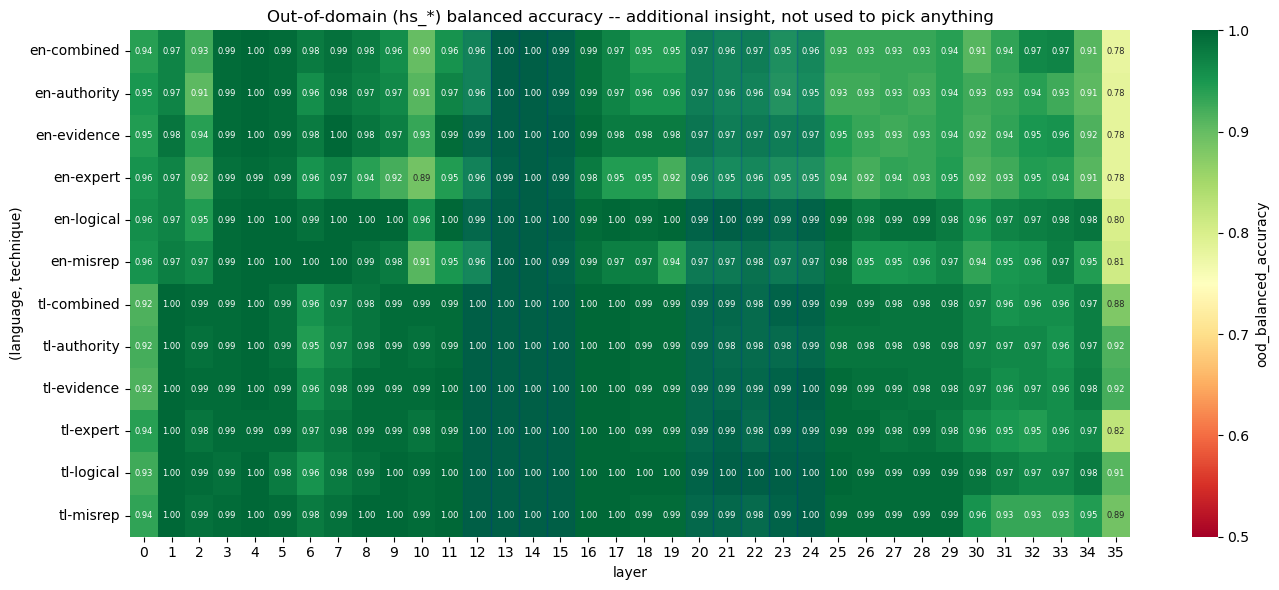

In [11]:
plot_accuracy_heatmap(results_df, "ood_balanced_accuracy", "Out-of-domain (hs_*) balanced accuracy -- additional insight, not used to pick anything")
plt.show()

### Verify combined directions against the saved `combined_vs_neutral_{en,tl}` directions

Re-deriving the MM direction from the full (unsplit, everyday-filtered)
dataset should reproduce the already-saved directions almost exactly (same
data, same `mean_diff` formula).

In [12]:
for lang, saved_name in [("en", "combined_vs_neutral_en"), ("tl", "combined_vs_neutral_tl")]:
    saved = load_file(str(DIRECTIONS_DIR / saved_name / "directions.safetensors"))
    saved_direction = saved["direction"].numpy()

    neutral_folder = LANGUAGES[lang]["neutral"]
    X_id, y_id = build_dataset(neutral_folder, LANGUAGES[lang]["techniques"], ID_FILTER_IN_DOMAIN)

    sims = []
    for layer in ALL_LAYERS:
        direction, _ = fit_mm_direction(X_id[:, layer, :], y_id)
        a, b = direction, saved_direction[layer]
        sims.append((a @ b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

    print(f"{lang}: min cosine sim vs. {saved_name} = {min(sims):.7f}")

en: min cosine sim vs. combined_vs_neutral_en = 0.9999999


tl: min cosine sim vs. combined_vs_neutral_tl = 0.9999999
